# Mise en place de la stratégie de Pairs Trading

## 0. Importation des librairies

In [2]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
from tqdm import tqdm
import os
import pandas_market_calendars as mcal
from itertools import combinations

import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("yfinance").setLevel(logging.CRITICAL)

## 1. Import de l'univers filtré

In [2]:
universe = pd.read_csv("filtered_universe.csv")
universe["start"] = pd.to_datetime(universe["start"])
universe["end"] = pd.to_datetime(universe["end"])
universe.head()

,ticker,start,end,data_length
0,AAL,2015-03-23,2024-07-08,2338
1,AAPL,1996-01-02,2026-01-14,7558
2,ABT,1996-01-02,2026-01-14,7558
3,ADM,1996-01-02,2026-01-14,7558
4,ADP,1996-01-02,2026-01-14,7558


In [3]:
universe.dtypes

ticker                 object
start          datetime64[ns]
end            datetime64[ns]
data_length             int64
dtype: object

## 2. Définition de l'univers en fonction des periodes de formation et de trading

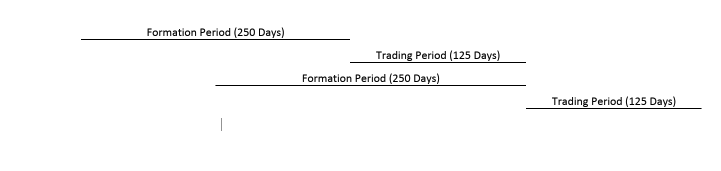

In [ ]:
def get_universe_by_period(universe, formation_period, trading_period, start_date, end_date=datetime(2025,1,1)):
    filtered_universe = []
    nyse = mcal.get_calendar("NYSE")

    schedule = nyse.schedule(start_date=start_date, end_date=end_date)
    trading_days = schedule.index  # jours ouverts bourse
    periods=[]
    for i in range(0, len(trading_days), trading_period):
        start = trading_days[i]
        formation_end = trading_days[min(i + formation_period, len(trading_days)-1)]
        trading_end = trading_days[min(i + formation_period + trading_period, len(trading_days)-1)]
        periods.append([start, formation_end, trading_end])
    
    for period_start, formation_end, trading_end in periods:
        tickers = universe[(universe["start"] <= period_start) & (universe["end"] >= trading_end)]["ticker"].unique()
        filtered_universe.append({
            "period_start": period_start,
            "formation_end": formation_end,
            "trading_end": trading_end,
            "tickers": tickers
        })

    return filtered_universe

universe_period = get_universe_by_period(universe, formation_period=250, trading_period=125, start_date=datetime(2020, 1, 1))


## 3. Calcul de la distance entre 2 Time series et du trigger (seuil)

In [5]:
def compute_closeness_trigger(series1, series2):
    # Calcul de la distance euclidienne
    distance = np.sum((series1/series1.iloc[0] - series2/series2.iloc[0]) ** 2)
    trigger = 2*np.std(series1/series1.iloc[0] - series2/series2.iloc[0])
    return distance, trigger

## 4. Pipeline de récupération des données de marchés

In [77]:
def get_data_from_cache(ticker, start_date, end_date, cache_dir="data_cache"):

    if not os.path.isdir(cache_dir):
        return None
    target_start = int(start_date.year)
    target_end = int(end_date.year)
    best_file = None
    best_span = None
    # Expected filename format: <TICKER>_<START_YEAR>_<END_YEAR>.csv
    for filename in sorted(os.listdir(cache_dir)):
        if not filename.endswith(".csv"):
            continue
        stem = os.path.splitext(filename)[0]
        parts = stem.rsplit("_", 2)
        if len(parts) != 3:
            continue
        file_ticker, start_year_str, end_year_str = parts
        if file_ticker != ticker:
            continue
        try:
            start_year = int(start_year_str)
            end_year = int(end_year_str)
        except ValueError:
            continue
        if start_year <= target_start and target_end <= end_year:
            span = end_year - start_year
            if best_span is None or span < best_span:
                best_span = span
                best_file = filename
    if best_file is None:
        return None
    data = pd.read_csv(
        os.path.join(cache_dir, best_file),
        index_col=0,
        parse_dates=True
    )
    if data.empty:
        return None
    data.index = pd.to_datetime(data.index, utc=True)
    start_ts = pd.Timestamp(start_date, tz="UTC")
    end_ts = pd.Timestamp(end_date, tz="UTC")
    data = data[(data.index >= start_ts) & (data.index <= end_ts)]
    return data if not data.empty else None



get_data_from_cache("AMD", datetime(2015,1,1), datetime(2020,1,1))

## 5. Mise en place de la stratégie

In [78]:
def pairs_trading_strategy(universe, start_date, end_date, formation_period, trading_period, top_n_pairs = 100, time_limit=25,cache_dir="data_cache"):

    universe_period = get_universe_by_period(universe, formation_period, trading_period, start_date, end_date)
    results = []
    
    for period in tqdm(universe_period, desc="Processing periods"):
        tickers = period["tickers"]
        start_p = period["period_start"]
        end_p = period["trading_end"]

        prices_dict = {}
        for ticker in tickers :
            try : 
                df = get_data_from_cache(ticker, start_p, end_p, cache_dir)
            except Exception as e:
                df = yf.Ticker(ticker).history(start=start_p, end=end_p)
                if not df.empty:
                    df.to_csv(os.path.join(cache_dir, f"{ticker}_{start_p.year}_{end_p.year}.csv"))
            if df is not None and not df.empty:
                prices_dict[ticker] = df["Close"].squeeze()
        if not prices_dict:
            continue

        prices_df = pd.DataFrame(prices_dict).dropna(axis=1, how='all')

        returns_df = prices_df.pct_change()
        formation_prices = prices_df.iloc[:formation_period]
        trading_prices = prices_df.iloc[formation_period:formation_period+trading_period]
        trading_returns = returns_df.iloc[formation_period:formation_period+trading_period]

        all_pairs_metrics = []

        for t1, t2 in combinations(prices_df.columns, 2):
            p1_form = formation_prices[t1].dropna()
            p2_form = formation_prices[t2].dropna()

            if len(p1_form) < formation_period *0.8 or len(p2_form) < formation_period *0.8:
                continue

            distance, trigger = compute_closeness_trigger(p1_form, p2_form)
            all_pairs_metrics.append({"t1": t1, "t2": t2, "distance": distance, "trigger": trigger})

        all_pairs_metrics = sorted(all_pairs_metrics, key=lambda x: x["distance"])
        top_pairs = all_pairs_metrics[:top_n_pairs]
        for pair in top_pairs:
            t1, t2 = pair["t1"], pair["t2"]
            distance, trigger = pair["distance"], pair["trigger"]

            p1_trading = trading_prices[t1].dropna()
            p2_trading = trading_prices[t2].dropna()

            if len(p1_trading)<trading_period*0.8 or len(p2_trading)<trading_period*0.8:
                continue

            norm_p1_trading = p1_trading / p1_trading.iloc[0]
            norm_p2_trading = p2_trading / p2_trading.iloc[0]

            pair_spread = (norm_p1_trading - norm_p2_trading).dropna()
            condition = abs(pair_spread) > trigger

            trading = False
            long_ticker, short_ticker = "", ""
            l0,s0 = .0,.0
            date_entry = None
            ret_entry = 0.0
            days_in_trade = 0
            

            for date, ret in pair_spread.items():
                cond = condition.loc[date]
                is_last_date = date == pair_spread.index[-1]

                if trading:
                    days_in_trade += 1
                if cond and not trading and not is_last_date:  # entrer en position
                    trading = True
                    ret_entry = ret
                    date_entry = date
                    if ret > 0:
                        long_ticker, short_ticker = t2, t1
                        l0 = trading_prices.loc[date, t2]
                        s0 = trading_prices.loc[date, t1]
                    else:
                        long_ticker, short_ticker = t1, t2
                        l0 = trading_prices.loc[date, t1]
                        s0 = trading_prices.loc[date, t2]
                elif trading and (not cond or is_last_date or days_in_trade >= time_limit):  # sortir de la position
                    trading = False
                    l1 = trading_prices.loc[date, long_ticker]
                    s1 = trading_prices.loc[date, short_ticker]

                    if is_last_date:
                        exit_reason = "End of Period"
                    elif days_in_trade >= time_limit:
                        exit_reason = f"Time Limit Reached ({days_in_trade} days)"
                    else:
                        exit_reason = "Convergence"

                    results.append({
                        "period_start": start_p,
                        "trading_end": end_p,
                        "Long": long_ticker,
                        "Short": short_ticker,
                        "distance": distance,
                        "return_diff_entry": ret_entry,
                        "return_diff_exit": ret,
                        "trigger": trigger,
                        "return": 0.5*(l1/l0 + s0/s1) - 1,
                        "date_entry": date_entry,
                        "date_exit": date,
                        "exit_reason": exit_reason,
                        "days_in_trade": days_in_trade
                    })

                    days_in_trade = 0

       
    return pd.DataFrame(results)

# results=pairs_trading_strategy(universe, start_date=datetime(2023,1,1), end_date=datetime(2024,6,1), formation_period=200, trading_period=50, top_n_pairs=100, time_limit=25, cache_dir="data_cache")

## 6. Calcul des résultats

In [79]:
def plot_hist(results):
    df = results.copy()
    fig = px.histogram(df, x="return", nbins=100, title="Distribution of Returns from Pairs Trading Strategy")
    fig.update_layout(xaxis_title="Return", yaxis_title="Frequency")
    return fig
# plot_hist(results)

In [88]:
def compute_equity(results, capital=100000, fees=0.001):
    if results is None or results.empty:
        return pd.DataFrame(columns=["date_exit", "daily_return_eq", "n_trades", "daily_net_return", "equity", "cumulative_return"])
    df = results.copy()
    df["date_exit"] = pd.to_datetime(df["date_exit"], utc=True, errors="coerce").dt.tz_convert(None).dt.normalize()
    df = df.dropna(subset=["date_exit", "return"])
    if df.empty:
        return pd.DataFrame(columns=["date_exit", "daily_return_eq", "n_trades", "daily_net_return", "equity", "cumulative_return"])
    daily = (
        df.groupby("date_exit")["return"]
        .agg(["mean", "size"])
        .rename(columns={"mean": "daily_return_eq", "size": "n_trades"})
        .sort_index()
        .reset_index()
    )
    # Fees are applied per trade closed on that day.
    daily["daily_net_return"] = daily["daily_return_eq"] - fees * daily["n_trades"]
    growth = (1 + daily["daily_net_return"]).clip(lower=1e-9)
    daily["equity"] = growth.cumprod() * capital
    daily["cumulative_return"] = daily["equity"] / capital - 1
    return daily

# compute_equity(results)

In [95]:
def plot_equity_curve(results, capital=100000):
    df = results.copy()
    if df.empty:
        fig = px.area(title="Equity Curve of Pairs Trading Strategy")
        fig.update_layout(xaxis_title="Date", yaxis_title="Equity")
        return fig

    df["date_exit"] = pd.to_datetime(df["date_exit"]).dt.tz_convert(None).dt.normalize()

    # Équipondération des trades qui sortent le même jour
    daily = compute_equity(df, capital=capital, fees=0.0005)

    fig = px.area(
        daily,
        x="date_exit",
        y="equity",
        title="Equity Curve (Capital réparti équipondéré par trade)"
    )
    fig.update_layout(xaxis_title="Date", yaxis_title="Equity")
    return fig

plot_equity_curve(results)

In [97]:
def compute_performance_metrics(results, capital=100000, fees=0.0005, risk_free_rate=0.0):
    daily = compute_equity(results, capital=capital, fees=fees)
    if daily.empty:
        return pd.DataFrame({
            "Total Return": 0.0,
            "Annualized Return": np.nan,
            "Annualized Volatility": np.nan,
            "Sharpe Ratio": np.nan,
            "Max Drawdown": np.nan,
            "Mean Days in Trade": np.nan
        }, index=[0])
    total_return = daily["equity"].iloc[-1] / capital - 1
    n_calendar_days = (daily["date_exit"].iloc[-1] - daily["date_exit"].iloc[0]).days + 1
    years = n_calendar_days / 365.25 if n_calendar_days > 0 else np.nan
    annualized_return = (1 + total_return) ** (1 / years) - 1 if years and years > 0 and total_return > -1 else np.nan
    daily_rets = daily["equity"].pct_change().dropna()
    annualized_volatility = daily_rets.std() * np.sqrt(252) if len(daily_rets) > 1 else np.nan
    if len(daily_rets) > 1 and daily_rets.std() > 0:
        rf_daily = (1 + risk_free_rate) ** (1 / 252) - 1
        sharpe_ratio = ((daily_rets - rf_daily).mean() / daily_rets.std()) * np.sqrt(252)
    else:
        sharpe_ratio = np.nan
    rolling_peak = daily["equity"].cummax()
    drawdown = daily["equity"] / rolling_peak - 1
    max_drawdown = drawdown.min() if not drawdown.empty else np.nan
    mean_days_in_trade = results["days_in_trade"].mean() if (results is not None and not results.empty and "days_in_trade" in results.columns) else np.nan
    return pd.DataFrame({
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown,
        "Mean Days in Trade": mean_days_in_trade
    }, index=[0])

compute_performance_metrics(results)

,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Mean Days in Trade
0,0.281906,0.026791,0.228305,0.249234,-0.653585,10.849825


## 7. Fonction de backtest et enregistrement des résultats

In [ ]:
def run_backtest_and_analyze(universe, start_date, end_date, formation_period, trading_period, top_n_pairs = 100, time_limit=25, cache_dir="data_cache", save_dir="results"):
    results = pairs_trading_strategy(universe, start_date, end_date, formation_period, trading_period, top_n_pairs, time_limit, cache_dir)
    performance_metrics = compute_performance_metrics(results)
    hist = plot_hist(results)
    equity_curve = plot_equity_curve(results)
    print("Performance Metrics:")
    for metric, value in performance_metrics.items():
        print(f"  {metric}: {value}")
    hist.show()
    equity_curve.show()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        os.makedirs(os.path.join(save_dir, f"backtest_results_{start_date.year}_{end_date.year}"), exist_ok=True)

        results.to_csv(os.path.join(save_dir, f"backtest_results_{start_date.year}_{end_date.year}", f"pairs_trading_results_{start_date.year}_{end_date.year}_{formation_period}_{trading_period}_{top_n_pairs}_{time_limit}.csv"), index=False)
        
        performance_metrics.to_csv(os.path.join(save_dir, f"backtest_results_{start_date.year}_{end_date.year}", f"performance_metrics_{start_date.year}_{end_date.year}_{formation_period}_{trading_period}_{top_n_pairs}_{time_limit}.csv"), index=False)
        hist.write_image(os.path.join(save_dir, f"backtest_results_{start_date.year}_{end_date.year}", f"return_distribution_{start_date.year}_{end_date.year}_{formation_period}_{trading_period}_{top_n_pairs}_{time_limit}.png"))
        equity_curve.write_image(os.path.join(save_dir, f"backtest_results_{start_date.year}_{end_date.year}", f"equity_curve_{start_date.year}_{end_date.year}_{formation_period}_{trading_period}_{top_n_pairs}_{time_limit}.png"))
        
    return performance_metrics, results
performance_metrics, results = run_backtest_and_analyze(universe, start_date=datetime(2015,1,1), end_date=datetime(2025,6,1), formation_period=250, trading_period=125, top_n_pairs=100, time_limit=25, cache_dir="data_cache", save_dir="results")

Processing periods: 100%|██████████| 21/21 [16:18<00:00, 46.58s/it]


In [72]:
performance_metrics

,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Mean Days in Trade
0,1.093186,0.912868,0.184346,4.951918,0.117031,10.250515


In [41]:
results.sort_values("return", ascending=True).head(10)

,period_start,trading_end,Long,Short,distance,return_diff_entry,return_diff_exit,trigger,return,date_entry,date_exit,exit_reason,days_in_trade
299,2015-01-02,2016-06-29,PG,WY,0.193611,0.276594,0.053078,0.055647,-0.115036,2016-02-19 05:00:00+00:00,2016-03-14 04:00:00+00:00,Convergence,16
3352,2018-12-21,2020-06-19,WEC,WELL,0.325459,0.416306,0.264435,0.071747,-0.113621,2020-05-14 04:00:00+00:00,2020-06-18 04:00:00+00:00,End of Period,24
3145,2018-12-21,2020-06-19,PEP,CB,0.262098,-0.306397,-0.136506,0.064622,-0.100987,2020-05-19 04:00:00+00:00,2020-06-18 04:00:00+00:00,End of Period,21
1303,2016-06-29,2017-12-22,SRE,CHD,0.149181,0.201334,0.006595,0.048853,-0.096936,2017-11-24 05:00:00+00:00,2017-12-21 05:00:00+00:00,End of Period,19
4756,2020-12-16,2022-06-14,VRTX,CLX,0.298354,-0.466191,-0.249331,0.066203,-0.094571,2022-04-07 04:00:00+00:00,2022-05-13 04:00:00+00:00,Time Limit Reached (25 days),25
4749,2020-12-16,2022-06-14,VRTX,CL,0.298354,-0.466191,-0.249331,0.066203,-0.094571,2022-04-07 04:00:00+00:00,2022-05-13 04:00:00+00:00,Time Limit Reached (25 days),25
3309,2018-12-21,2020-06-19,AEP,CB,0.311521,0.199088,0.035117,0.056388,-0.092172,2020-05-15 04:00:00+00:00,2020-06-04 04:00:00+00:00,Convergence,13
5370,2021-12-14,2023-06-13,MGM,NWSA,0.252315,-0.226995,-0.035158,0.062775,-0.088925,2023-04-26 04:00:00+00:00,2023-05-30 04:00:00+00:00,Convergence,23
1619,2016-12-27,2018-06-25,ECL,PEP,0.112382,0.278491,0.113616,0.042396,-0.083194,2018-05-18 04:00:00+00:00,2018-06-22 04:00:00+00:00,End of Period,24
6393,2023-06-13,2024-12-09,LMT,SRE,0.227289,0.221525,0.014189,0.058874,-0.082596,2024-10-07 04:00:00+00:00,2024-11-06 05:00:00+00:00,Convergence,22


In [10]:
yf.Ticker("AAL").info

{'address1': '1 Skyview Drive',
 'city': 'Fort Worth',
 'state': 'TX',
 'zip': '76155',
 'country': 'United States',
 'phone': '682 278 9000',
 'website': 'https://www.aa.com',
 'industry': 'Airlines',
 'industryKey': 'airlines',
 'industryDisp': 'Airlines',
 'sector': 'Industrials',
 'sectorKey': 'industrials',
 'sectorDisp': 'Industrials',
 'longBusinessSummary': 'American Airlines Group Inc., through its subsidiaries, operates as a network air carrier in the United States, Latin America, Atlantic, and Pacific. The company provides scheduled air transportation services for passengers and cargo through its hubs in Charlotte, Chicago, Dallas/Fort Worth, Los Angeles, Miami, New York, Philadelphia, Phoenix, and Washington, D.C., as well as through partner gateways in London, Doha, Madrid, Seattle/Tacoma, Sydney, and Tokyo. It also operates a mainline fleet of 1,013 aircraft. The company was formerly known as AMR Corporation and changed its name to American Airlines Group Inc. in December